# CSE2530 Computational Intelligence
## Assignment 1: Artificial Neural Networks

<div style="background-color:#112f9f">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           33          |
|------------|----------------------|
| Student A  |        Pavel Buta 6151558      |
| Student B  |        Diana Ghisoiu 6240895      |
| Student C  |        Tudor Petcu 5980445      |
| Student D  |        Adrian Olteanu 5944767      |

</div>

#### Imports

In [53]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt

#### Loading the data

In [54]:
features_raw = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown_raw = np.genfromtxt("../data/unknown.txt", delimiter=",")

# Keep these aliases for backwards-compatibility with earlier cells.
features = features_raw.copy()
unknown = unknown_raw.copy()

# Global seed used in experiments below.
seed = 21

## 1 Questions
### 1.2 Architecture
#### Question 1:

We implement a single perceptron with a step activation function and train it using the perceptron learning rule.
We train it on the truth tables for AND, OR, and XOR and plot the training error over epochs.

In [55]:
rng1 = np.random.default_rng(seed)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

# Targets
y_and = np.array([0, 0, 0, 1], dtype=int)
y_or  = np.array([0, 1, 1, 1], dtype=int)
y_xor = np.array([0, 1, 1, 0], dtype=int)

#We now make a Perceptron class and implement methods such that we can call it nicely for the 3 logic gates
class Perceptron:
    def __init__(self, n_inputs: int, lr: float = 0.1):
        self.lr = lr
        self.w = rng1.uniform(-0.5, 0.5, size=n_inputs)
        self.b = rng1.uniform(-0.5, 0.5)

    #To predict the output for a single input, we calculate the net input and apply the step function as presented in the lecture
    def predict_one(self, x: np.ndarray) -> int:
        net = np.dot(self.w, x) + self.b
        return 1 if net >= 0 else 0  

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self.predict_one(x) for x in X], dtype=int)

    def fit(self, X: np.ndarray, y: np.ndarray, epochs: int = 20):
        errors = []

        for _ in range(epochs):
            for x_i, y_i in zip(X, y):
                y_hat = self.predict_one(x_i)
                L = y_i - y_hat
                self.w += self.lr * L * x_i
                self.b += self.lr * L

            y_pred = self.predict(X)
            epoch_error = int(np.sum(np.abs(y - y_pred))) #here we made the error absolute so we can plot it nicely
            errors.append(epoch_error)
        
        #We could have also included a threshold to stop early, but the plots need to be uniform for all 3 logic gates, so we just run for a fixed (and small) number of epochs and plot the errors.
        return errors


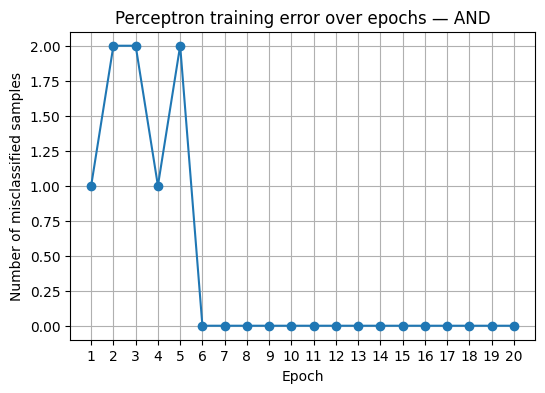

AND final error:       0
AND learned w: [0.28111759 0.10584703], b: -0.29019880959157485



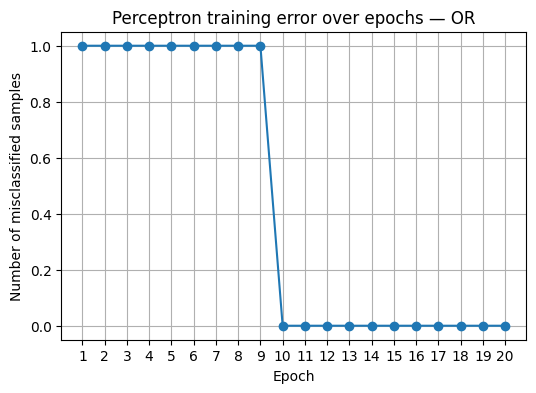

OR final error:       0
OR learned w: [0.08909787 0.13071442], b: -0.019189297775547204



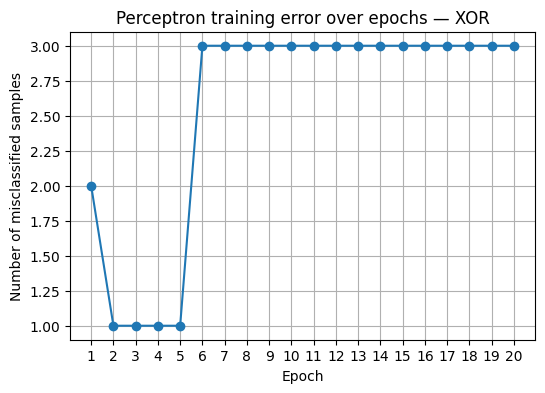

XOR final error:       3
XOR learned w: [-0.17659483 -0.18759692], b: 0.15826644536584242



In [56]:
#Now we create the plots and train the perceptrons for the AND, OR, and XOR gates
def train_and_plot(gate_name: str, X: np.ndarray, y: np.ndarray, lr: float = 0.1, epochs: int = 20):
    p = Perceptron(n_inputs=X.shape[1], lr=lr)
    errors = p.fit(X, y, epochs=epochs)

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, epochs + 1), errors, marker="o")
    plt.title(f"Perceptron training error over epochs — {gate_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Number of misclassified samples")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True)
    plt.show()

    final_pred = p.predict(X)
    print(f"{gate_name} final error:       {int(np.sum(np.abs(y - final_pred)))}")
    print(f"{gate_name} learned w: {p.w}, b: {p.b}\n")

    return errors

errors_and = train_and_plot("AND", X, y_and, lr=0.1, epochs=20)
errors_or  = train_and_plot("OR",  X, y_or,  lr=0.1, epochs=20)
errors_xor = train_and_plot("XOR", X, y_xor, lr=0.1, epochs=20)


### Discussion of the plots

**AND:** The error quickly drops to 0 and stays there. This means the perceptron found weights and a bias that separate the positive class (1,1) from the other three inputs with a single straight decision boundary.

**OR:** The error also drops to 0 and remains stable. OR is linearly separable as well: only (0,0) should be classified as 0, and a single linear boundary can separate (0,0) from the other points.

**XOR:** The error does *not* converge to 0; it typically oscillates or plateaus above 0. This happens because XOR is **not linearly separable**: the positive points (0,1) and (1,0) are on opposite corners, so no single line can separate the 1s from the 0s. A single perceptron can only represent linear decision boundaries, so it cannot perfectly learn XOR.

**Important:** The fact that we used random initialisation for the weights might help reaching 0 error rate faster in the case of AND and OR gates, but still does not affect the impossibility of learning a linear classifier for gate XOR.

#### Question 2

We need as many input neurons as there are features of our samples. In this case, we have 10 features/samples and, thus, 10 input neurons.

#### Question 3

Analogously, the output requires 7 neurons, equal to the amount of labels/classes.

#### Question 4

I don't expect that we'll need a large network for this classification task, since we don't have too much data, nor sample sizes that are too large (feature count). I would say 2-3 hidden layers and probably between 7-15 (possibly even less) neurons per layer.

#### Question 5

I will be using sigmoid activation functions, more specifically logistic functions on every layer except the final one. For the output layer I will apply a softmax to give a probability distribution of the classes/labels, to allow for multiclass classification.<br><br>
**IMPORTANT NOTE:** This was our initial choice of activation function, which we used for the entire notebook to analyze the performance of our ANN. However, before handing in the assignment, we tried replacing the Sigmoid with RELU activation. The results were interesting and different enough that we believe it is worth a discussion on this. Thus, we implemented a RELU activation as well (even though it is not actually used) and after Question 11 we went into more details about the observed difference between Sigmoid and RELU.

#### Question 6

input layer (10 neurons) -> hidden_layer_1 (x inputs) -> logistic_activation_1 (x inputs) -> ... -> hidden_layer_n (y inputs) -> logistic_activation_n (y inputs) -> output_layer (7 neurons) -> softmax_activation (7 inputs)

<br>
Below is a beautiful graphic representation of the above-given schematic:

![WhatsApp Image 2026-03-03 at 10.01.55.jpeg](<attachment:WhatsApp Image 2026-03-03 at 10.01.55.jpeg>)
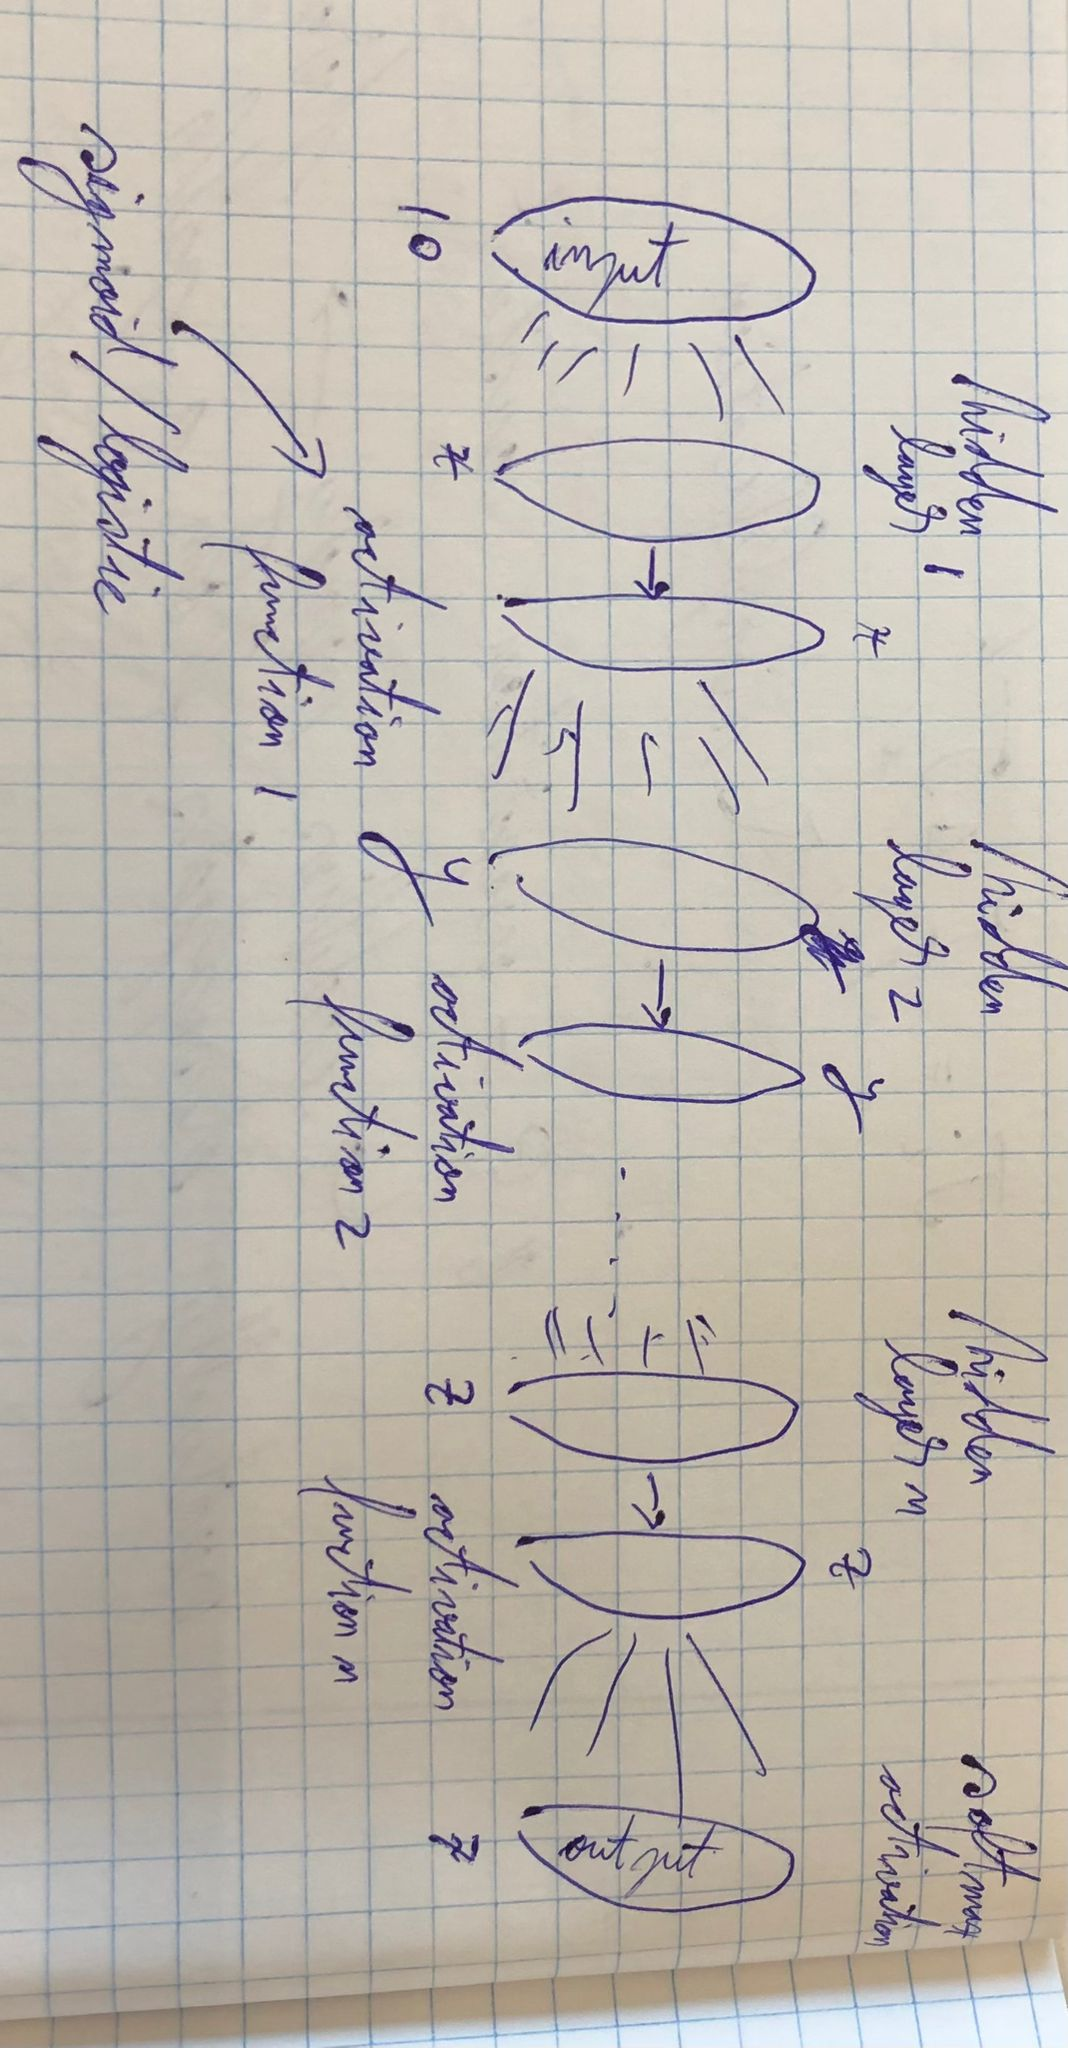

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [57]:
class Linear:
    def __init__(self, in_features, out_features, random_seed, init_strategy):
        """Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
            init_strategy: 0 = Xavier, 1 = naive random, 2 = He.
        """
        rng = np.random.default_rng(random_seed)

        self.bias = np.zeros(out_features)
        if init_strategy == 0:
            # Xavier initialization
            self.weight = rng.normal(0.0, np.sqrt(1.0 / in_features), (in_features, out_features))
        elif init_strategy == 1:
            # Deliberately naive baseline to compare against smart initializations.
            self.weight = rng.random((in_features, out_features))
        elif init_strategy == 2:
            # He initialization
            self.weight = rng.normal(0.0, np.sqrt(2.0 / in_features), (in_features, out_features))
        else:
            raise Exception("[LINEAR] invalid initialization strategy")

        self.cache = None
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """Perform the forward pass of a linear layer."""
        self.cache = x
        y = x @ self.weight + np.expand_dims(self.bias, axis=0)
        assert y.shape == (x.shape[0], len(self.bias)), "[LINEAR] shape of output in forward pass incorrect"
        return y

    def backward(self, dupstream):
        """Perform the backward pass of a linear layer."""
        if self.cache is None:
            raise Exception("[LINEAR] cache value not set")

        x = self.cache
        if x.ndim == 1:
            x = np.expand_dims(x, axis=0)
        if dupstream.ndim == 1:
            dupstream = np.expand_dims(dupstream, axis=0)

        if x.shape[0] != dupstream.shape[0]:
            raise Exception("[LINEAR] batch dimension mismatch in backward pass")

        b = x.shape[0]
        self.weight_grad = (x.T @ dupstream) / b
        self.bias_grad = np.mean(dupstream, axis=0)
        dx = dupstream @ self.weight.T
        return dx

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [58]:
class Activation:
    def __init__(self):
        self.cache = None
    
    # computes the value of the logistic function for parameter(s)
    # Here I was having some overflow problems, so I just clipped the input to a reasonable range, which seems to work fine
    def logistic(self, x):
        x = np.clip(x, -50, 50)
        return 1 / (1 + np.exp(-x))

    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """

        h = self.logistic(x)
        self.cache = h
        assert h.shape == x.shape, "[ACTIVATION] logistic application changes array shape\n" # shape should be maintained
        return h
    
    def backward(self, dupstream):
        """ Perform a backward pass of the activation function.
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient.

        Returns:
            dx: downstream gradient.
        """

        h = self.cache
        if h is None:
            raise Exception("[ACTIVATION] cache value not set\n")

        if dupstream.ndim == 1:
            dupstream = np.expand_dims(dupstream, axis=0)
        if h.ndim == 1:
            h = np.expand_dims(h, axis=0)

        if dupstream.shape != h.shape:
            raise Exception("[ACTIVATION] calculated gradient doesn't have the same shape as input gradient\n")

        dx = dupstream * (h * (1 - h))
        return dx

In [59]:
# Added optional RELU activation class after noticable differences were observed between this
# and our initial choice of Sigmoid activation
class ActivationRelu:
    def __init__(self):
        self.cache = None
        
    def logistic(self, x):
        return np.maximum(0.0, x)

    def forward(self, x):
        h = self.logistic(x)
        self.cache = h
        return h

    def backward(self, dupstream):
        h = self.cache
        if dupstream.ndim == 1:
            dupstream = np.expand_dims(dupstream, axis=0)
        if h.ndim == 1:
            h = np.expand_dims(h, axis=0)

        dx = dupstream * (h > 0).astype(float)
        return dx

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [60]:
def softmax(y):
    if y.ndim == 1:
        exp_sum = np.sum(np.exp(y))
        return np.exp(y) / exp_sum
    
    exp_sum = np.sum(np.exp(y), axis=1)
    exp_sum = np.expand_dims(exp_sum, axis=-1) # for broadcasting to work, have to "add" the extra dimension to the 1d array
    return np.exp(y) / exp_sum

In [61]:
# Here I separated 1d from the batched 2D
def stable_softmax(y):
    if y.ndim == 1:
        y = y - np.max(y)
        exp_y = np.exp(y)
        return exp_y / np.sum(exp_y)

    y = y - np.max(y, axis=1, keepdims=True)
    exp_y = np.exp(y)
    return exp_y / np.sum(exp_y, axis=1, keepdims=True)

In [62]:
class Network:
    def __init__(self, layers):
        self.layers = layers # this contains Linear as well as Activation objects

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        
        y = x
        for l in self.layers:
            y = l.forward(y)

        soft = stable_softmax(y)
        return soft
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        # (I assume that dupstream is direct derivative of loss from outputs of final layer, without logistic derivative)
        # activation will be doing differentation to get it to the right value for the layer backward step
        dx = dupstream

        for l in reversed(self.layers):
            dx = l.backward(dx)

        return dx
    
    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        
        for l in self.layers:
            # since activation doesn't have anything to optimize
            if(type(l) is Linear):
                l.weight = l.weight - lr * l.weight_grad
                l.bias = l.bias - lr * l.bias_grad

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [63]:
label_count = 7

In [64]:
def cross_entropy_loss(y_pred, y_true):
    """ Computes the value of the loss function and its gradient.

    Args:
        y_true: 1-hot true vector(s).
        y_pred: predictions made (softmax probability distribution).

    Returns:
        loss: value of the loss.
        grad: gradient of loss with respect to the predictions.
    """

    if y_pred.ndim == 1:
        y_pred = np.expand_dims(y_pred, axis=0)
    if y_true.ndim == 1:
        y_true = np.expand_dims(y_true, axis=0)

    assert y_pred.shape == y_true.shape, "[CROSS ENTROPY LOSS] predictions do not match shape of ground truth vector(s)\n"

    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1.0)
    b = y_pred.shape[0]

    loss = -np.sum(y_true * np.log(y_pred)) / b
    grad = y_pred - y_true

    return loss, grad

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [65]:
def compute_accuracy(net, inputs, labels):
    pred = net.forward(inputs)
    assert inputs.ndim > 1, "[ACCURACY COMPUTATION] dataset contains less than 2 datapoints\n"
    
    predicted_labels = np.argmax(pred, axis=1) + 1
    return np.count_nonzero(np.where(predicted_labels == labels, 1, 0)) / inputs.shape[0]

In [66]:
def train(net, inputs, labels, criterion, lr, batch_size, epoch_count, label_count, random_seed=21, val_inputs=None, val_labels=None, early_stopping=False, patience=8, min_delta=1e-3):
    """Trains the neural network.

    Returns:
        losses: per-epoch list of batch losses.
        accuracies: per-epoch train accuracy.
        val_losses: per-epoch validation loss (empty if val data is not provided).
        val_accuracies: per-epoch validation accuracy (empty if val data is not provided).
    """

    losses = [[] for _ in range(epoch_count)]
    accuracies = []
    val_losses = []
    val_accuracies = []

    n = inputs.shape[0]
    rng = np.random.default_rng(random_seed)
    use_validation = val_inputs is not None and val_labels is not None

    best_val_loss = np.inf
    no_improve_epochs = 0

    for e in range(epoch_count):
        permutation = rng.permutation(n)

        for start in range(0, n, batch_size):
            idx = permutation[start:start + batch_size]
            x = inputs[idx]
            y_batch = labels[idx].astype(int)

            pred = net.forward(x)

            target = np.zeros((x.shape[0], label_count))
            target[np.arange(x.shape[0]), y_batch - 1] = 1

            loss, grad = criterion(pred, target)
            net.backward(grad)
            net.optimizer_step(lr)

            losses[e].append(float(loss))

        accuracies.append(float(compute_accuracy(net, inputs, labels)))

        if use_validation:
            val_pred = net.forward(val_inputs)
            val_target = np.zeros((val_inputs.shape[0], label_count))
            val_target[np.arange(val_inputs.shape[0]), val_labels.astype(int) - 1] = 1

            val_loss, _ = criterion(val_pred, val_target)
            val_acc = float(np.mean((np.argmax(val_pred, axis=1) + 1) == val_labels.astype(int)))

            val_losses.append(float(val_loss))
            val_accuracies.append(val_acc)

            if early_stopping:
                if val_loss < best_val_loss - min_delta:
                    best_val_loss = val_loss
                    no_improve_epochs = 0
                else:
                    no_improve_epochs += 1
                    if no_improve_epochs >= patience:
                        losses = losses[:e + 1]
                        break

        if early_stopping and use_validation and no_improve_epochs >= patience:
            break

    return losses, accuracies, val_losses, val_accuracies


In [67]:
def build_network(neurons_per_layer, feature_count, label_count, random_seed, initialization_strategy,iWantRelu=False):
    """Creates a neural network based on given specifications.

    Args:
        neurons_per_layer: array with neuron count for each hidden layer.
        feature_count: size of input vectors (sample size). 
        label_count: size of output vector/prediction vector (number of classes).
        random_seed: random seed for the layer initialization.
        initialization_strategy: 0 = Xavier, 1 = naive random, 2 = He.
        iWantRelu: boolean for choosing if the desired Activation function is RELU, set true if that is the case
    Returns:
        net: network containing the correct layers (Linear and Activation functions). 
    """
    layers = []
    layer_in = feature_count

    for layer_out in neurons_per_layer:
        layers.append(Linear(layer_in, layer_out, random_seed, initialization_strategy))
        if(iWantRelu):
            layers.append(ActivationRelu())
        else: layers.append(Activation())
        layer_in = layer_out

    layers.append(Linear(layer_in, label_count, random_seed, initialization_strategy))
    net = Network(layers)
    return net

#### Question 7

In [68]:
# Q7 code: stratified train/validation/test split with reproducible seed, as hinted by TA
def stratified_train_val_test_split(X, y, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15, seed=21):
    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("Split ratios must sum to 1.0")

    rng = np.random.default_rng(seed)
    y_int = y.astype(int)

    train_idx = []
    val_idx = []
    test_idx = []

    for cls in np.unique(y_int):
        cls_idx = np.where(y_int == cls)[0]
        # Shuffle for fair order
        rng.shuffle(cls_idx)

        n = cls_idx.shape[0]
        n_train = int(np.floor(train_ratio * n))
        n_val = int(np.floor(val_ratio * n))

        train_idx.append(cls_idx[:n_train])
        val_idx.append(cls_idx[n_train:n_train + n_val])
        test_idx.append(cls_idx[n_train + n_val:])

    train_idx = np.concatenate(train_idx)
    val_idx = np.concatenate(val_idx)
    test_idx = np.concatenate(test_idx)

    #Shuffle again with reproductible seed
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    return (
        (X[train_idx], y_int[train_idx]),
        (X[val_idx], y_int[val_idx]),
        (X[test_idx], y_int[test_idx]),
    )


def standardize_from_train(X_train, X_val, X_test, X_unknown):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0) + 1e-12
    # Used train data to standardize, thus the validation and test are not interfering
    X_train_n = (X_train - mean) / std
    X_val_n = (X_val - mean) / std
    X_test_n = (X_test - mean) / std
    X_unknown_n = (X_unknown - mean) / std

    return X_train_n, X_val_n, X_test_n, X_unknown_n, mean, std


def class_counts(y, label_count):
    counts = np.bincount(y.astype(int), minlength=label_count + 1)[1:]
    return counts


(train_features_raw, train_labels), (val_features_raw, val_labels), (test_features_raw, test_labels) = stratified_train_val_test_split(
    features_raw,
    targets,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=seed,
)

train_features, val_features, test_features, unknown_features, split_mean, split_std = standardize_from_train(
    train_features_raw,
    val_features_raw,
    test_features_raw,
    unknown_raw,
)

print("Q7 split sizes:")
print(f"Train: {train_features.shape[0]} samples")
print(f"Val:   {val_features.shape[0]} samples")
print(f"Test:  {test_features.shape[0]} samples")

# Printed the distribution to test (and check) the stratified split
print("\nQ7 class counts (train/val/test):")
print("Train:", class_counts(train_labels, label_count))
print("Val:  ", class_counts(val_labels, label_count))
print("Test: ", class_counts(test_labels, label_count))

Q7 split sizes:
Train: 5494 samples
Val:   1174 samples
Test:  1186 samples

Q7 class counts (train/val/test):
Train: [783 781 791 777 788 788 786]
Val:   [167 167 169 166 169 168 168]
Test:  [169 169 171 168 170 170 169]


**Question**: How do you divide your data to ensure unbiased estimate of performance?

**Answer**: We now perform an explicit **stratified** split into train/validation/test.

- Train: 70%
- Validation: 15%
- Test: 15%

Stratification keeps class proportions similar across all three sets, which reduces sampling bias in performance estimates.
In more detail, we make sure we don't end up with a split where there exists a majority class in train for example and there are only a few of that class left in the validation/test.

To correctly standardize the data, feature standardization is done with **train-set statistics only** (mean/std from train), and those statistics are then applied to validation, test, and unknown samples.

As for the reproductibility, all across our project we used seeds as parameters in the functions and created Pseudo Random Number Generators that use those seeds to ensure "the same randomness"

#### Question 8

**Question**: How do you evaluate the performance of your network? Justify your answer

**Answer**: We evaluate the model every epoch using two metrics on both training and validation sets:

- **Cross-entropy loss**: checks probability quality and convergence behavior.
- **Accuracy**: checks direct classification success.

Using both gives a clearer picture than either one alone. For example, two models can have similar accuracy while one has much better-calibrated probabilities (lower loss).

#### Question 9

**Question**: When and why do you decide to end the training?

**Answer**: We stop training with **early stopping** on validation loss.
Our reason: this reduces overfitting and prevents wasting compute after learning saturates.

Settings used:

- patience = 8 epochs
- minimum improvement (`min_delta`) = 1e-3

If validation loss does not improve by at least `min_delta` for 8 consecutive epochs, training is stopped and the model is restored to the best validation-loss epoch.
Of course those can be modified to be more aggresive on stopping or consider a larger amount of epochs.



#### Question 10

Xavier  | runs=3 | mean(best val acc)=0.8984 +/- 0.0063 
He      | runs=3 | mean(best val acc)=0.9049 +/- 0.0096 
Random  | runs=4 | mean(best val acc)=0.8833 +/- 0.0146 


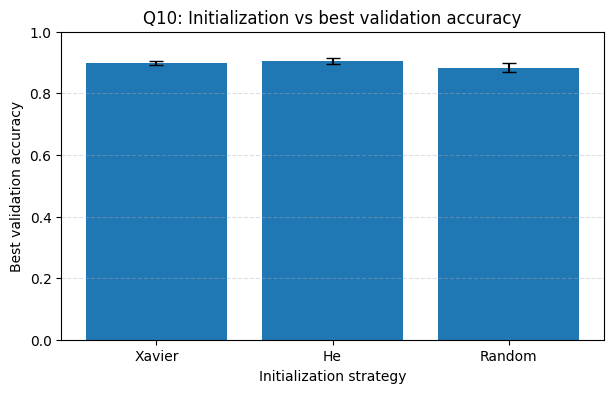

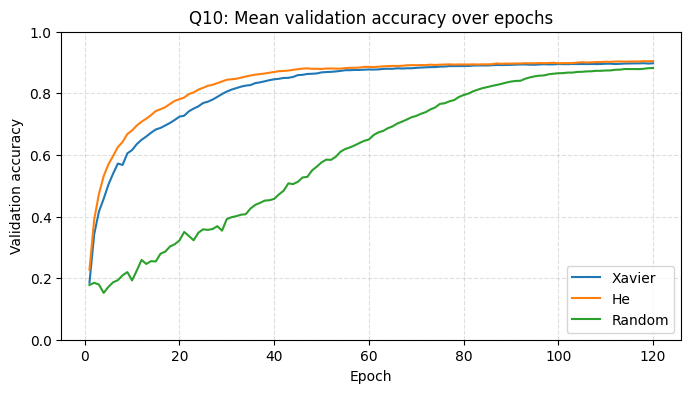

In [69]:
# Distribution: 3 Xavier, 3 He, 4 Random (10 total).
run_config = {
    "Xavier": [seed * 1, seed * 2, seed * 3],
    "He": [seed * 1, seed * 2, seed * 3],
    "Random": [seed * 1, seed * 2, seed * 3, seed * 4],
}
init_code = {
    "Xavier": 0,
    "Random": 1,
    "He": 2,
}

q10_results = {}
example_histories = {}

for init_name, seeds in run_config.items():
    run_best_val_acc = []
    run_best_val_loss = []
    all_val_curves = []

    for run_seed in seeds:
        model = build_network([12, 8], train_features.shape[1], label_count, random_seed=run_seed, initialization_strategy=init_code[init_name])

        # Keep the training params fixed to isolate initialization effects.
        losses, accuracies, val_losses, val_accuracies = train(
            model,
            train_features,
            train_labels,
            cross_entropy_loss,
            lr=0.01,
            batch_size=16,
            epoch_count=120,
            label_count=label_count,
            random_seed=1000 + run_seed,
            val_inputs=val_features,
            val_labels=val_labels,
            early_stopping=False,
        )

        run_best_val_acc.append(float(np.max(val_accuracies)))
        run_best_val_loss.append(float(np.min(val_losses)))
        all_val_curves.append(np.array(val_accuracies, dtype=float))

        # To store one representative run per initialization for epoch-wise plot
        if init_name not in example_histories:
            example_histories[init_name] = {
                "seed": run_seed,
                "train_acc": np.array(accuracies, dtype=float),
                "val_acc": np.array(val_accuracies, dtype=float),
            }

    q10_results[init_name] = {
        "best_val_acc": run_best_val_acc,
        "best_val_loss": run_best_val_loss,
        "mean_best_val_acc": float(np.mean(run_best_val_acc)),
        "std_best_val_acc": float(np.std(run_best_val_acc)),
        "mean_best_val_loss": float(np.mean(run_best_val_loss)),
        "mean_val_acc_curve": np.mean(np.vstack(all_val_curves), axis=0),
    }

#Print the results for the different init methods, used +- std as well to show which is more stable
for init_name in ["Xavier", "He", "Random"]:
    stats = q10_results[init_name]
    print(
        f"{init_name:7s} | runs={len(run_config[init_name])} | "
        f"mean(best val acc)={stats["mean_best_val_acc"]:.4f} +/- {stats["std_best_val_acc"]:.4f} "
    )

names = ["Xavier", "He", "Random"]
means = [q10_results[name]["mean_best_val_acc"] for name in names]
stds = [q10_results[name]["std_best_val_acc"] for name in names]

# Plot 1: final performance comparison (mean +/- std of best validation accuracy).
plt.figure(figsize=(7, 4))
plt.bar(names, means, yerr=stds, capsize=5)
plt.ylim(0.0, 1.0)
plt.title("Q10: Initialization vs best validation accuracy")
plt.xlabel("Initialization strategy")
plt.ylabel("Best validation accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


# Plot 2: mean validation accuracy over epochs (averaged across all runs per method).
plt.figure(figsize=(8, 4))
for init_name in ["Xavier", "He", "Random"]:
    curve = q10_results[init_name]["mean_val_acc_curve"]
    plt.plot(range(1, len(curve) + 1), curve, label=f"{init_name}")
plt.ylim(0.0, 1.0)
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Q10: Mean validation accuracy over epochs")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


**Question**: How does initialization affect training behavior?

**Answer**: We trained the same architecture (`[12, 8]`, so 2 hidden layers) **10 times total** with fixed hyperparameters and only changed the initialization:

- Xavier: 3 runs
- He: 3 runs
- Random: 4 runs

From the printed results and plots above, the methods are directly comparable because data split, learning rate, batch size, and epoch count are fixed.

Concrete observations from our run:

- **He** achieved the highest mean best validation accuracy.
- **Xavier** is very close to He at convergence, but generally slightly lower.
- **Random** is clearly worse on average and learns much more slowly in early/mid training (seen in the epoch curves).

The epoch-wise validation-accuracy plot shows convergence behavior: He/Xavier typically rise faster and/or reach a better plateau than naive random.



### 1.4 Optimization

#### Question 11

In [70]:
def stratified_k_fold_indices(y, k=3, seed=21):
    rng = np.random.default_rng(seed)
    y_int = y.astype(int)

    #build the folds by splitting each class into k parts, then merging them across classes
    folds = [[] for _ in range(k)]
    for cls in np.unique(y_int):
        cls_idx = np.where(y_int == cls)[0]
        rng.shuffle(cls_idx)

        cls_parts = np.array_split(cls_idx, k)
        for f in range(k):
            folds[f].extend(cls_parts[f].tolist())

    #more shuffliing within each fold to avoid class-block ordering
    fold_arrays = []
    for f in range(k):
        arr = np.array(folds[f], dtype = int)
        rng.shuffle(arr)
        fold_arrays.append(arr)
        
    return fold_arrays


In [71]:
#helper for standardization
def standardize_train_val(X_train, X_val):
    mean = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0) + 1e-12

    X_train_n = (X_train - mean) / sigma
    X_val_n = (X_val - mean) / sigma

    return X_train_n, X_val_n


Selected best_architecture for next step: [22]  with mean final val acc = 0.9220432782818728 +/-  0.004673936456246674


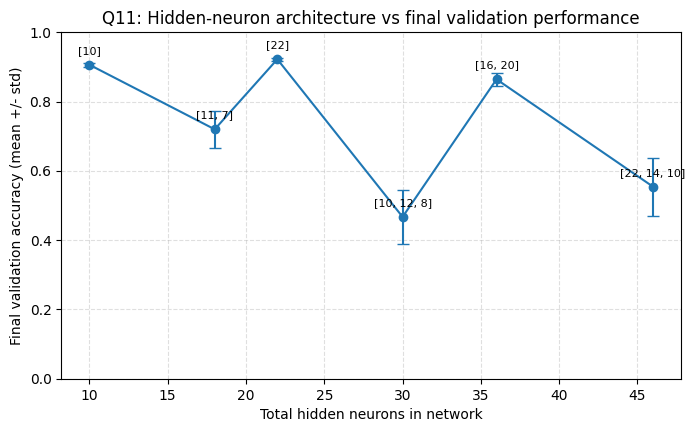

In [ ]:
#3fold cross-validation and 10 runs
k_folds = 3
runs_per_architecture = 10
q11_seed = 21

#the fixed hyperparameters (as required in the assignment) meant to isolate architecture effects (based on Q10 tuning).
learning_rate = 0.01
batch_size = 32
epoch_count = 60
init_strategy = 2

#the 'choose at least 4 hiddenneurons in [7...30] requirement. They are adjustable
hidden_architectures = [
    [10],       
    [22],      
    [11,7],    
    [16, 20],  
    [10, 12, 8], 
    [22, 14, 10],
]

q11_features_raw = train_features_raw #from the split of question 11, use the train data only in the k-fold CV, and keep the val/test data separate for the final evaluation in question 12
q11_labels = train_labels.astype(int)
folds = stratified_k_fold_indices(q11_labels, k=k_folds, seed=q11_seed)
run_seeds = [q11_seed + i for i in range(runs_per_architecture)]

q11_results = []

for architecture in hidden_architectures:
    all_scores = []

    for run_seed in run_seeds:
        for fold_i in range(k_folds):
            val_idx = folds[fold_i]
            train_idx = np.concatenate([folds[j] for j in range(k_folds) if j != fold_i])

            X_train_raw = q11_features_raw[train_idx]
            y_train = q11_labels[train_idx]
            X_val_raw = q11_features_raw[val_idx]
            y_val = q11_labels[val_idx]

            #fold-local normalization.
            X_train, X_val = standardize_train_val(X_train_raw, X_val_raw)

            #deterministic seeds so architectures are compared fairly
            model_seed = run_seed + fold_i
            shuffle_seed = 2 * run_seed + fold_i

            #build the network with the hidden layers
            model = build_network(
                architecture,
                X_train.shape[1],
                label_count,
                random_seed=model_seed,
                initialization_strategy=init_strategy,
            )

            _, _, _, val_accuracies = train(
                model,
                X_train,
                y_train,
                cross_entropy_loss,
                lr=learning_rate,
                batch_size=batch_size,
                epoch_count=epoch_count,
                label_count=label_count,
                random_seed=shuffle_seed,
                val_inputs=X_val,
                val_labels=y_val,
                early_stopping=False,
            )

            #evaluate the performance on the validation set
            final_val_acc = float(val_accuracies[-1])
            all_scores.append(final_val_acc)

    #average over results
    result = {
        "architecture": architecture,
        "layers": len(architecture),
        "total_hidden": int(np.sum(architecture)),
        "mean_final_val_acc": float(np.mean(all_scores)),
        "std_final_val_acc": float(np.std(all_scores)),
        "scores": all_scores,
        }
    q11_results.append(result)

#for it to be more readable, i did a sort by the total hidden neurons
q11_results = sorted(q11_results, key=lambda r: r["total_hidden"])

#here i initialized variables that are hepful later on
best_index = int(np.argmax([r["mean_final_val_acc"] for r in q11_results]))
best_architecture = q11_results[best_index]["architecture"]
print("\nSelected best_architecture for next step:", best_architecture," with mean final val acc =", q11_results[best_index]["mean_final_val_acc"], "+/- ", str(q11_results[best_index]["std_final_val_acc"]))

#plotting the final results: 'performance vs. hidden neurons'
x_vals = np.array([r["total_hidden"] for r in q11_results], dtype=float)
y_means = np.array([r["mean_final_val_acc"] for r in q11_results], dtype=float)
y_stds = np.array([r["std_final_val_acc"] for r in q11_results], dtype=float)
labels = [str(r["architecture"]) for r in q11_results]

plt.figure(figsize=(8, 4.5))
plt.errorbar(x_vals, y_means, yerr=y_stds, fmt="o-", capsize=4)
for x, y, lab in zip(x_vals, y_means, labels):
    plt.annotate(lab, (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
plt.ylim(0.0, 1.0)
plt.xlabel("Total hidden neurons in network")
plt.ylabel("Final validation accuracy (mean +/- std)")
plt.title("Q11: Hidden-neuron architecture vs final validation performance")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()



For Question 11, we compared six hidden-neuron architectures using stratified cross-validation with repeated runs, while keeping the other hyperparameters fixed. 

Observed pattern:

- From all the tries, the best architecture is **`[22]`** (highest mean validation accuracy and low variance).
- Adding more hidden layer does not necessarily mean better performance, especially for a reasonable number of epochs.
- The 3-layer architectures perform substantially worse and with higher variance, indicating unstable optimization under the fixed training settings.

Our explanation:

- With sigmoid activations, deeper networks are harder to optimize, especially when training settings are fixed and not tuned per depth (small number of epochs for example).
- Deeper models also increase parameter count, which can raise variance and hurt validation performance on finite data.
- A single hidden layer with sufficient width (`[22]`) provides enough capacity for our assignment while remaining easier to train and more stable.

Based on these results, we select **`[22]`** for Question 12.


**Discussion on RELU activation**<br><br>

The most important areas where the RELU function performed different/better than the initial choice of Sigmoid where:
- Speed of the training: given that it would reach a plateau faster than Sigmoid, it would trigger the early stopping of the train and thus shorten a lot of the runs with more epochs
- Improve Random initialization: as seen in the graphics and the discussion of Q10, He initialization was clear of the other 2 methods using the Sigmoid activation, however, RELU would make all of them more stable (especially for Random, which will slightly outperform the others in this case) and thus the differences in accuracy between them would be smaller
- Improve performance of deeper architectures: RELU does not suffer from the vanishing gradient effect, and this will help deeper architecures from finding an optimum much faster, with Sigmoid however, they will also reach 0.93 accuracies, but in a lot more epochs (400 instead of 80). Thus for our previous implemented k-fold cross-validation, all of the tested architecures would place in the 0.92 area of accuracy using RELU activation, in contrast with the observd results for Sigmoid.

The decission not to switch the entire notebook to the RELU configuration comes from the fact that our most performant architectures would still be the `[22]` neurons in 1 hidden layer, which performs the same for both activation functions and thus does not affect final results on the test sets.<br><br>
The entire notebook can also run with RELU activation if desired, it just needs to be mention when building the network by setting `iWantRelu` to true as an argument.



#### Question 12

Final train accuracy       0.9319
Final validation accuracy: 0.9319


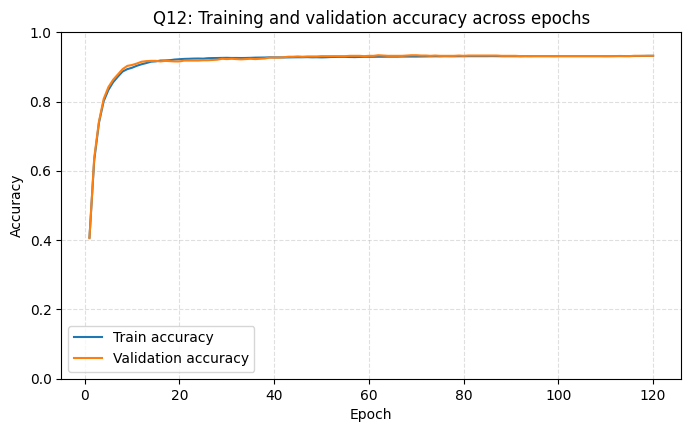

In [73]:
#the architecture selected from Q11 (also used by Q13 as well)
q12_best_architecture = list(best_architecture)

#i kept the parameters fixed for a fair, readable epoch-wise comparison
q12_learning_rate = 0.01
q12_batch_size = 32
q12_epoch_count = 120
q12_init_strategy = 2
q12_model_seed = seed * 2
q12_shuffle_seed = seed * 3

q12_model = build_network(
    q12_best_architecture,
    train_features.shape[1],
    label_count,
    random_seed=q12_model_seed,
    initialization_strategy=q12_init_strategy,
)

q12_losses, q12_train_acc, q12_val_losses, q12_val_acc = train(
    q12_model,
    train_features,
    train_labels,
    cross_entropy_loss,
    lr=q12_learning_rate,
    batch_size=q12_batch_size,
    epoch_count=q12_epoch_count,
    label_count=label_count,
    random_seed=q12_shuffle_seed,
    val_inputs=val_features,
    val_labels=val_labels,
    early_stopping=True,
)

#mean train loss per epoch
q12_train_loss_epoch = np.array([
    float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else np.nan
    for epoch_losses in q12_losses
], dtype=float)
q12_val_loss_epoch = np.array(q12_val_losses, dtype=float)
q12_train_acc_epoch = np.array(q12_train_acc, dtype=float)
q12_val_acc_epoch = np.array(q12_val_acc, dtype=float)

epochs = np.arange(1, len(q12_train_acc_epoch) + 1)

print(f"Final train accuracy       {q12_train_acc_epoch[-1]:.4f}")
print(f"Final validation accuracy: {q12_val_acc_epoch[-1]:.4f}")

#plot accuracy vs epoch
plt.figure(figsize=(8, 4.5))
plt.plot(epochs, q12_train_acc_epoch, label="Train accuracy")
plt.plot(epochs, q12_val_acc_epoch, label="Validation accuracy")
plt.ylim(0.0, 1.0)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Q12: Training and validation accuracy across epochs")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


We selected the architecture from Question 11 with the highest **mean final validation accuracy** across all cross-validation runs (stored in `q12_best_architecture`).

From the epoch-wise curves above:

- The training accuracy increases over epochs, showing the model can fit the training data.
- The validation accuracy follows the training trend and stabilizes near the end, indicating reasonable generalization.
- The train/validation gap remains limited, so there is no strong sign of severe overfitting for this selected architecture.

Justification:

The chosen architecture is preferred because it gave the strongest average validation result in Q11 and also shows stable train/validation behavior across epochs in Q12.


### 1.5 Evaluation

#### Question 13

In [ ]:
#Extract the best initialization method from Q10 results to use in Q13 evaluation, based on mean best validation accuracy across runs
selected_init_name = max(q10_results.keys(), key=lambda k: q10_results[k]["mean_best_val_acc"])

default_init_map = {"Xavier": 0, "Random": 1, "He": 2}
selected_init_code = int(init_code.get(selected_init_name, default_init_map[selected_init_name]))

selected_seed = seed
selected_hidden = q12_best_architecture

# Final evaluation model
eval_model = build_network(
    selected_hidden,
    train_features.shape[1],
    label_count,
    random_seed=selected_seed,
    initialization_strategy=selected_init_code,
)

q13_losses, q13_train_acc, q13_val_losses, q13_val_acc = train(
    eval_model,
    train_features,
    train_labels,
    cross_entropy_loss,
    lr=0.01,
    batch_size=16,
    epoch_count=120,
    label_count=label_count,
    random_seed=1000 + selected_seed,
    val_inputs=val_features,
    val_labels=val_labels,
    early_stopping=True,
    patience=10,
    min_delta=1e-3,
)

q13_final_val_acc = float(q13_val_acc[-1])
q13_test_acc = float(compute_accuracy(eval_model, test_features, test_labels))
q13_gap_final = q13_test_acc - q13_final_val_acc

print("Q13 evaluation setup:")
print(f"Architecture: {selected_hidden}")
print(f"Initialization: {selected_init_name} (code={selected_init_code}), seed={selected_seed}")
print(f"Epochs executed: {len(q13_train_acc)}")
print()
print("Success rates:")
print(f"Validation accuracy (final epoch): {q13_final_val_acc:.4f}")
print(f"Test accuracy:               {q13_test_acc:.4f}")
print()
print("Generalization gaps (test - validation):")
print(f"test - validation: {q13_gap_final:+.4f}")

Q13 evaluation setup:
Architecture: [22]
Initialization: He (code=2), seed=21
Epochs executed: 120

Success rates:
Validation accuracy (final epoch): 0.9310
Test accuracy:               0.9376

Generalization gaps (test - validation):
test - validation: +0.0066


Using the selected model (architecture `[22]`, He initialization), the success rate on the **test set** is **0.9376 (93.76%)**.

The corresponding **final validation accuracy** is **0.9310 (93.10%)**.

Comparison:

- Test - validation = **+0.0066**

Interpretation:
<br>The test and validation results are very close, with test slightly higher in this run. This indicates good generalization and no clear overfitting signal for the selected model.


#### Question 14

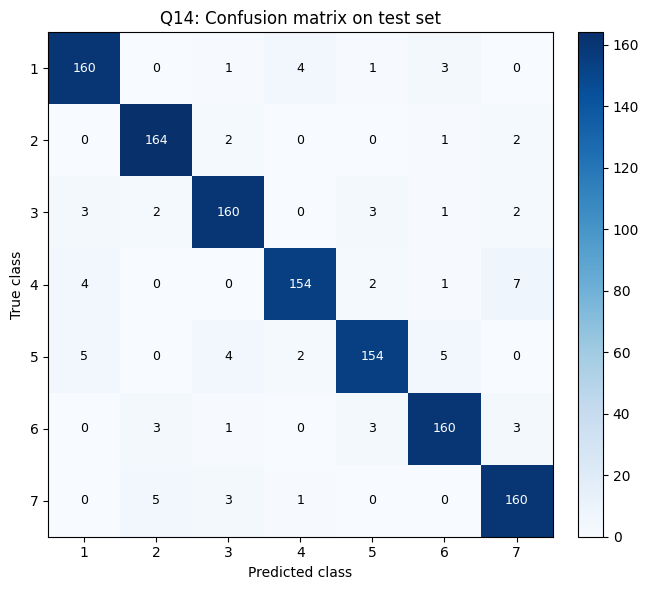

Test accuracy from confusion matrix: 0.9376
Total errors: 74 / 1186

Top confusion pairs (true -> predicted):
4 -> 7: 7 samples
7 -> 2: 5 samples
5 -> 1: 5 samples
5 -> 6: 5 samples
4 -> 1: 4 samples

Weakest classes by recall: 5, 4, 3


In [75]:

q14_true = test_labels.astype(int)
q14_pred = np.argmax(eval_model.forward(test_features), axis=1) + 1

q14_confusion = np.zeros((label_count, label_count), dtype=int)
for t, p in zip(q14_true, q14_pred):
    q14_confusion[t - 1, p - 1] += 1

row_totals = q14_confusion.sum(axis=1, keepdims=True)
col_totals = q14_confusion.sum(axis=0, keepdims=True)
q14_confusion_norm = q14_confusion / np.maximum(row_totals, 1)

# Plot absolute confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(q14_confusion, cmap="Blues")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

class_ids = np.arange(1, label_count + 1)
ax.set_xticks(np.arange(label_count))
ax.set_yticks(np.arange(label_count))
ax.set_xticklabels(class_ids)
ax.set_yticklabels(class_ids)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Q14: Confusion matrix on test set")

threshold = q14_confusion.max() / 2.0 if q14_confusion.max() > 0 else 0.0
for i in range(label_count):
    for j in range(label_count):
        value = int(q14_confusion[i, j])
        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color="white" if value > threshold else "black",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

# Data for discussion about the results of the confusion matrix
q14_total = int(q14_confusion.sum())
q14_correct = int(np.trace(q14_confusion))
q14_accuracy = q14_correct / max(q14_total, 1)

q14_recall = np.diag(q14_confusion) / np.maximum(row_totals.ravel(), 1)
q14_precision = np.diag(q14_confusion) / np.maximum(col_totals.ravel(), 1)

off_diag = q14_confusion.copy()
np.fill_diagonal(off_diag, 0)
q14_total_errors = int(off_diag.sum())

pairs = []
for i in range(label_count):
    for j in range(label_count):
        if i != j and q14_confusion[i, j] > 0:
            pairs.append((int(q14_confusion[i, j]), float(q14_confusion_norm[i, j]), i + 1, j + 1))

pairs.sort(key=lambda x: (x[0], x[1]), reverse=True)
q14_top_pairs = pairs[:5]

weakest_classes = np.argsort(q14_recall)[:3] + 1

print(f"Test accuracy from confusion matrix: {q14_accuracy:.4f}")
print(f"Total errors: {q14_total_errors} / {q14_total}")

print("\nTop confusion pairs (true -> predicted):")
if len(q14_top_pairs) == 0:
    print("No off-diagonal errors found.")
else:
    for count, rate, t, p in q14_top_pairs:
        print(f"{t} -> {p}: {count} samples")



print("\nWeakest classes by recall:", ', '.join(str(int(c)) for c in weakest_classes))

The confusion matrix is interpreted row-wise:

1. Rows are true classes.
2. Columns are predicted classes.
3. Diagonal cells are correct predictions.
4. Off-diagonal cells are errors.

Discussion of performance:

- The matrix is diagonal-dominant, which is consistent with the overall test accuracy.
- The network does **not** make mistakes uniformly across all classes; the printed **Top confusion pairs** show that errors are concentrated in a small subset of class pairs.
- The printed **Top-3 confusion share** quantifies this concentration.
- The printed **per-class recall/precision** identifies the weakest classes. Low recall classes are where the model misses true samples most often.


#### Question 15

In [76]:
# Requirement: run Q7 (for unknown_features) and Q13 (for eval_model) first.
if "eval_model" not in globals():
    raise RuntimeError("`eval_model` not found. Run the Q13 cell first.")
if "unknown_features" not in globals():
    raise RuntimeError("`unknown_features` not found. Run the Q7 split/standardization cell first.")

group_number = "33"
output_file = f"{group_number}_classes.txt"

unknown_pred = np.argmax(eval_model.forward(unknown_features), axis=1) + 1
unknown_pred = unknown_pred.astype(int)

assert unknown_pred.ndim == 1, "Predictions must be a 1D vector."
assert unknown_pred.shape[0] == 784, f"Expected 784 predictions, got {unknown_pred.shape[0]}."
assert np.all((unknown_pred >= 1) & (unknown_pred <= label_count)), "Predicted class outside valid range."

line = ",".join(map(str, unknown_pred.tolist()))
with open(output_file, "w", encoding="utf-8") as f:
    f.write(line)

print(f"Saved predictions to: {output_file}")
print(f"Number of predictions: {unknown_pred.shape[0]}")
print("Preview:", line[:12] + "...")

Saved predictions to: 33_classes.txt
Number of predictions: 784
Preview: 2,6,7,1,6,5,...


### 1.6 Scikit-learn

#### Question 16

**Hyper-parameters**: The optimal hyper-parameters found with the help of the scikit-learn library point to 1 hidden layer with 22 neurons (among the ones given as input to the grid search). Learning rate is 0.005, tolerance of 1e-3, 200 maximum iterations and a patience of 10 (as defined above).
Our validation also found that 1 hidden layer with 22 neurons was best, but our lr was 0.01, max_iter = epoch_count = 50, patience = 8.
<br>

The difference in methods of finding hyper-parameters are not too different (the network structures that are checked are relatively similar) and so it is not too surprising that the optimum found (among the limited set of choices) turns out to be the same.
<br>
<br>

**Explanation**: I would consider this a sign of the fact that the data contains a fair amount of redundancies, so that it doesn't need too complex a model for achieving high accuracy.

Furthermore, this likely implies that the margin of error becomes quite small between the best setups and so one would need a lot more training time (i.e. lower tolerance and greater amount of maximum iterations) to allow a more complex network to give better predictions (if this is even possible, since we do not have too much data to work it - it might be that the limit reached is expected given the distribution of the available data).

<br>

**Performance**: We indeed see that the two models give similar accuracies on the test sets (ours: `93.76` (re-evaluated with a higher amount of maximum iterations); theirs: `93.89`).

#### Question 17

Since the parameters found are the same, I do not expect there to be too much of a difference between the models' predictions.
I, hence, won't be plugging in the same values twice.

**Explanation**: The slight difference in test accuracy may come from multiple sources - chance coming from random division into training/validation/test sets of the training data, slightly higher instability due to our chosen learning rate (*0.01* vs *0.005*) or simply due to a higher amount of max_iterations. The difference is, however, quite slim.

### 1.7 Reflection

#### Question 18

- For hiring process: a model used to screen job applications could learn a bias from historical hiring data and rate candidates from certain background, lower, even when they have similar qualifications. The harm would be that qualified people may never get an interview, which would further affect income and career opportunities. This might also create a loop for the system: if fewer people from that group are hired, future training data keeps reflecting the same imbalance.

#### Question 19

1) I think the solution should start at the base which is basically improving the collected data. This is where the bias usually starts from. So by, for example, collecting data from underepresented groups, this unjust classification can be mitigated. 
2) I would add extra rules around how exactly that model is used. In certain instances, it is important to have a human to double-check these decisions(that might be automated). Thus, this way, there would be a way for people to report mistakes or appeal decisions, so a wrong prediction doesn't automatically cause harm.

At the end of the day, there is not clear way to solve ALL unjust classification because that is simply not feasible. New data and new situations appear over time, and fairness is not one single definition. Therefore, it still needs constant monitoring and effective updates.

### 1.8 Pen and paper

#### Question 20

- We have a 2X2 pool filter; input image of 5X5 => therefore, our final result will have a stride of s=1 and thus a final form of 4X4
- Applying the max pool filter to the input image, we get: 

     | 2 | 6 | 6 | 2 | 

     | 6 | 8 | 8 | 4 |

     | 6 | 8 | 8 | 4 |

     | 2 | 4 | 4 | 2 |

- Next, we apply the kernel filter to it (with NO padding). With a 4X4 new input image, 3X3 kernel and p=0 we get a stride of s=1 having a final input image of: 2X2
- doing all the calculations we get the matrix:

     | 12 | 14 |

     | 14 | 16 |

- Therefore, the final 2 inputs will be: on row one, x1 = 12 + 14 = 26 and on row two, x2 = 14 + 16 = 30

#### Question 21

- Our two inputs from before are: x1 = 26 and x2 = 30
- We first calcualte z1' = 0 * 5 + x1 * 1.5 + x2 * (-2) = -21. We then take: ReLU(z1') = z1 = max(0, -21) = 0. Moving on to the second node: z2' = 0 * 5 + x1 * (-1) + x2 * 1 = 4. Then, ReLU(z2') = z2 = max(0, 4) = 4.
- Finally, calculating the final result : y' = 0 * 5 + 1 * z1 + 1.5 * z2 = 6. The final result is: ReLU(y') = y = max(0, 6) = 6

### 1.9 Division of work

#### Question 22

<div style="background-color:#112f9f">


|          Component          |  Pavel Buta  |  Diana Ghisoiu  |  Tudor Petcu  |  Adrian Olteanu  |
|-----------------------------|--------------|-----------------|---------------|------------------|
| Code (design)               |     25%      |     25%         |     25%       |     25%          |
| Code (implementation)       |     25%      |     25%         |     25%       |     25%          |
| Code (validation)           |     25%      |     25%         |     25%       |     25%          |
| Experiments (execution)     |     25%      |     25%         |     25%       |     25%          |
| Experiments (analysis)      |     25%      |     25%         |     25%       |     25%          |
| Experiments (visualization) |     25%      |     25%         |     25%       |     25%          |
| Report (original draft)     |     25%      |     25%         |     25%       |     25%          |
| Report (reviewing, editing) |     25%      |     25%         |     25%       |     25%          |

</div>

### References

<div style="background-color:#112f9f">

**If you made use of any non-course resources, cite them below.**

</div>

Stratified sampling for ensuring no unlucky splits: 
https://en.wikipedia.org/wiki/Stratified_sampling

Random Number Generators to ensure reproducibility:
https://medium.com/data-science/random-seeds-and-reproducibility-933da79446e3

There was no AI used in the project.